In [3]:
from __future__ import annotations

from typing import Any

import numpy as np

from fast_control_implement import fast_control_implement
from mat_utils import load_mat, as_1d, as_2d
from max_profit_1 import max_profit_1
from max_profit_t import max_profit_t


def _normalize_param(param: Any) -> Any:
    param.price_e = as_1d(param.price_e)
    param.price_reg = as_2d(param.price_reg)
    param.hourly_Mileage = as_1d(param.hourly_Mileage)
    param.hourly_Distribution = as_2d(param.hourly_Distribution)
    param.d_s = as_1d(param.d_s)
    param.index_none_reg = as_1d(param.index_none_reg).astype(int)
    param.s_perf = float(param.s_perf)
    return param


def _normalize_param_std(param_std: Any) -> Any:
    param_std.energy_init = as_1d(param_std.energy_init)
    param_std.energy_upper_limit = as_2d(param_std.energy_upper_limit)
    param_std.energy_lower_limit = as_2d(param_std.energy_lower_limit)
    param_std.power_dis_upper_limit = as_2d(param_std.power_dis_upper_limit)
    param_std.power_dis_lower_limit = as_2d(param_std.power_dis_lower_limit)
    param_std.power_ch_upper_limit = as_2d(param_std.power_ch_upper_limit)
    param_std.power_ch_lower_limit = as_2d(param_std.power_ch_lower_limit)
    param_std.theta = as_1d(param_std.theta)
    param_std.eta_ch = as_2d(param_std.eta_ch)
    param_std.eta_dis = as_2d(param_std.eta_dis)
    param_std.pr_dis = as_1d(param_std.pr_dis)
    param_std.pr_ch = as_1d(param_std.pr_ch)
    param_std.wOmiga = as_2d(param_std.wOmiga)
    return param_std

In [4]:
day_price = 21
mat_path = f"../data_prepare/param_day_{day_price}.mat"
data = load_mat(mat_path).raw

param = _normalize_param(data["param"])
param_std = _normalize_param_std(data["param_std"])

Signal_day = as_1d(data["Signal_day"])
NOFSLOTS = int(np.asarray(data["NOFSLOTS"]).squeeze())
NOFDER = int(np.asarray(data["NOFDER"]).squeeze())
NOFSCEN = int(np.asarray(data["NOFSCEN"]).squeeze())
delta_t = float(np.asarray(data["delta_t"]).squeeze())
M = float(np.asarray(data.get("M", 1e6)).squeeze())
delta_t_req = float(np.asarray(data.get("delta_t_req", 0.5)).squeeze())

NOFTCAP_bid = 900
NOFTCAP_ctrl = 30

result = {
    "P_alloc": np.zeros((NOFDER, 0)),
    "actualMil": np.zeros(NOFSLOTS),
    "actualEnergy": np.zeros(NOFSLOTS),
    "actualCost": np.zeros(NOFSLOTS),
}

ctx = {
    "param": param,
    "param_std": param_std,
    "Signal_day": Signal_day,
    "NOFSLOTS": NOFSLOTS,
    "NOFDER": NOFDER,
    "NOFSCEN": NOFSCEN,
    "delta_t": delta_t,
    "delta_t_req": delta_t_req,
    "M": M,
    "NOFTCAP_ctrl": NOFTCAP_ctrl,
    "result": result,
}

max_profit_1(ctx)

for t_cap in range(1, (NOFSLOTS - 1) * 1800 + 1):
    if t_cap % NOFTCAP_bid == 1:
        delta_t_rest = delta_t - ((t_cap - 1) % 1800) / 1800.0
        ctx.update({"t_cap": t_cap, "delta_t_rest": delta_t_rest})
        max_profit_t(ctx)
    if t_cap % NOFTCAP_ctrl == 1:
        ctx.update({"t_cap": t_cap})
        fast_control_implement(ctx)

for t_cap in range((NOFSLOTS - 1) * 1800 + 1, NOFSLOTS * 1800):
    if t_cap % NOFTCAP_ctrl == 1:
        ctx.update({"t_cap": t_cap})
        fast_control_implement(ctx)

result["actualEnegyFee"] = param.price_e * result["actualEnergy"]
result["actualProfit"] = (
    param.price_reg[:, 0] * result["Bid_R_rev"] * param.s_perf
    + (param.price_reg[:, 1] * result["actualMil"]) * param.s_perf
)
result["actualProfit"] = result["actualProfit"] * delta_t

e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\atoms\affine\reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\.venv\lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


Set parameter LicenseID to value 2771980
slot 1: bidding ok
slot 1: rolling bid ok at t_cap 1
slot 1: rolling bid ok at t_cap 901
slot 2: rolling bid ok at t_cap 1801
slot 2: rolling bid ok at t_cap 2701
slot 3: rolling bid ok at t_cap 3601
slot 3: rolling bid ok at t_cap 4501
slot 4: rolling bid ok at t_cap 5401
slot 4: rolling bid ok at t_cap 6301
slot 5: rolling bid ok at t_cap 7201
slot 5: rolling bid ok at t_cap 8101
slot 6: rolling bid ok at t_cap 9001
slot 6: rolling bid ok at t_cap 9901
slot 7: rolling bid ok at t_cap 10801
slot 7: rolling bid ok at t_cap 11701
slot 8: rolling bid ok at t_cap 12601
slot 8: rolling bid ok at t_cap 13501
slot 9: rolling bid ok at t_cap 14401
slot 9: rolling bid ok at t_cap 15301
slot 10: rolling bid ok at t_cap 16201
slot 10: rolling bid ok at t_cap 17101
slot 11: rolling bid ok at t_cap 18001
slot 11: rolling bid ok at t_cap 18901
slot 12: rolling bid ok at t_cap 19801
slot 12: rolling bid ok at t_cap 20701
slot 13: rolling bid ok at t_cap 21601

In [6]:
print(result.keys())

dict_keys(['P_alloc', 'actualMil', 'actualEnergy', 'actualCost', 'Bid_R_init', 'Bid_P_init', 'E_init', 'Bid_R_cur', 'Bid_P_cur', 'E_cur', 'P_DER_cur', 'R_DER_cur', 'Bid_R_rev', 'Bid_P_rev', 'P_DER_rev', 'R_DER_rev', 'E_rev', 'p_none_reg', 'p_dis', 'p_ch', 'actualEnegyFee', 'actualProfit'])


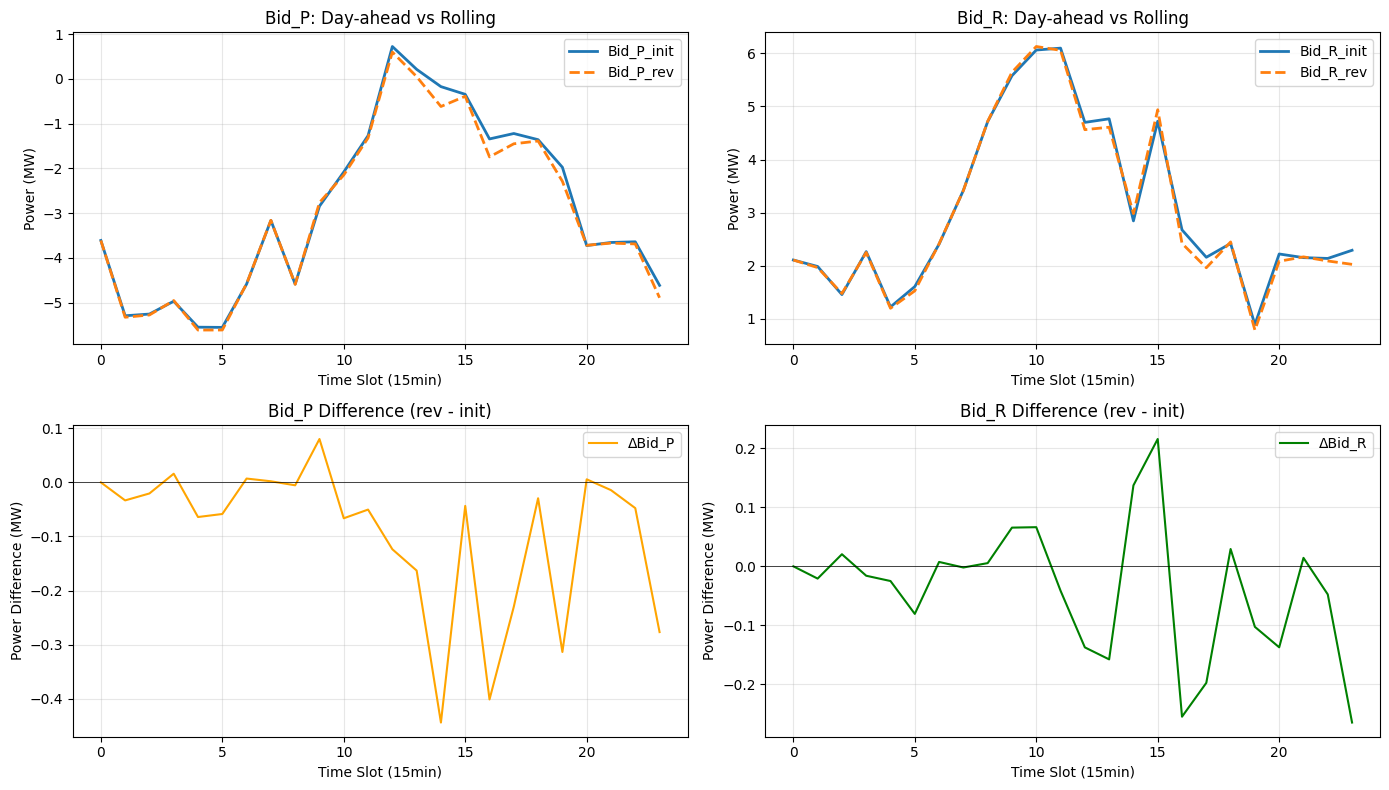

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Bid_P 对比
axes[0, 0].plot(result["Bid_P_init"], label="Bid_P_init", linewidth=2)
axes[0, 0].plot(result["Bid_P_rev"], label="Bid_P_rev", linewidth=2, linestyle="--")
axes[0, 0].set_xlabel("Time Slot (15min)")
axes[0, 0].set_ylabel("Power (MW)")
axes[0, 0].set_title("Bid_P: Day-ahead vs Rolling")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Bid_R 对比
axes[0, 1].plot(result["Bid_R_init"], label="Bid_R_init", linewidth=2)
axes[0, 1].plot(result["Bid_R_rev"], label="Bid_R_rev", linewidth=2, linestyle="--")
axes[0, 1].set_xlabel("Time Slot (15min)")
axes[0, 1].set_ylabel("Power (MW)")
axes[0, 1].set_title("Bid_R: Day-ahead vs Rolling")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 差异
axes[1, 0].plot(result["Bid_P_rev"] - result["Bid_P_init"], label="ΔBid_P", color="orange")
axes[1, 0].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1, 0].set_xlabel("Time Slot (15min)")
axes[1, 0].set_ylabel("Power Difference (MW)")
axes[1, 0].set_title("Bid_P Difference (rev - init)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(result["Bid_R_rev"] - result["Bid_R_init"], label="ΔBid_R", color="green")
axes[1, 1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1, 1].set_xlabel("Time Slot (15min)")
axes[1, 1].set_ylabel("Power Difference (MW)")
axes[1, 1].set_title("Bid_R Difference (rev - init)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()